# Notebook 2 — Kaggle-Ready Privacy-Preserving Heterogeneous Real-Time Federated Learning

This is the main dissertation notebook.

It contains the three required parts:

1. **Real-time FL:** ECG data arrives in streaming chunks per round.
2. **Heterogeneous FL:** clients have non-IID data, different dataset sizes, different learning rates, different local epochs, and simulated latency.
3. **Privacy-preserving FL:** local updates are clipped, Gaussian noise is added, and secure aggregation is simulated.

MongoDB is removed so the notebook is Kaggle-ready.

In [1]:
# ============================================================
# Kaggle-ready setup
# Project: Cardiovascular Disease Prediction using a
# Privacy-Preserving Heterogeneous Real-Time Federated Learning Framework
# ============================================================

import os, time, zipfile, random, warnings, math, json
from pathlib import Path
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    matthews_corrcoef, classification_report, confusion_matrix,
    roc_curve, auc, balanced_accuracy_score
)
from sklearn.preprocessing import label_binarize

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Input, Conv1D, BatchNormalization, MaxPooling1D, Dropout,
    LayerNormalization, Bidirectional, LSTM, GlobalMaxPooling1D,
    Dense
)

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

2026-06-26 15:16:56.685776: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782487016.873915      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782487016.931501      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782487017.372080      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782487017.372122      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782487017.372130      58 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# ============================================================
# Data loading utilities
# Supports:
# 1. Kaggle datasets mounted under /kaggle/input
# 2. Zenodo download fallback, if Kaggle internet is enabled
# 3. Synthetic ECG fallback, for debugging only
# ============================================================

CLIENT_ZENODO_TEMPLATE = "https://zenodo.org/records/16739305/files/ecg_aug_model{client_id}.zip?download=1"
TEST_ZENODO_URL = "https://zenodo.org/records/16730029/files/test_models.zip?download=1"

DATA_DIR = Path("/kaggle/working/dataset")
TEST_DIR = Path("/kaggle/working/test_models")
DATA_DIR.mkdir(parents=True, exist_ok=True)

def unzip_file(zip_path, extract_dir):
    extract_dir = Path(extract_dir)
    extract_dir.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(extract_dir)
    return extract_dir

def find_npz_dir(root, contains=None):
    root = Path(root)
    candidates = []
    for p in root.rglob("*"):
        if p.is_dir() and list(p.glob("*.npz")):
            candidates.append(p)
    if contains:
        contains = str(contains)
        for p in candidates:
            if contains in str(p):
                return p
    return candidates[0] if candidates else None

def download_file(url, output_path):
    import requests
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    print(f"Downloading: {url}")
    with requests.get(url, stream=True, timeout=120) as r:
        r.raise_for_status()
        with open(output_path, "wb") as f:
            for chunk in r.iter_content(chunk_size=8192):
                if chunk:
                    f.write(chunk)
    print("Saved:", output_path)
    return output_path

def process_npz_files(directory):
    directory = Path(directory)
    files = sorted(directory.glob("*.npz"))
    if len(files) == 0:
        raise FileNotFoundError(f"No .npz files found in {directory}")
    X, y = [], []
    for fp in tqdm(files, desc=f"Loading {directory.name}"):
        with np.load(fp) as data:
            X.append(data["x"])
            y.append(int(np.array(data["y"]).item()))
    X = np.asarray(X).astype("float32")
    labels = np.asarray(y)
    classes, indexed = np.unique(labels, return_inverse=True)
    y_1hot = np.eye(len(classes), dtype="float32")[indexed]
    return X, y_1hot, classes

def make_synthetic_ecg(n_samples=1200, n_classes=6, timesteps=600, channels=8):
    print("WARNING: Using synthetic ECG-like data only because real data was not found.")
    X = np.random.normal(0, 0.5, size=(n_samples, timesteps, channels)).astype("float32")
    labels = np.random.randint(0, n_classes, size=n_samples)
    t = np.linspace(0, 1, timesteps)
    for i in range(n_samples):
        cls = labels[i]
        freq = 3 + cls
        signal = np.sin(2 * np.pi * freq * t) + 0.3*np.sin(2*np.pi*(freq*2)*t)
        X[i, :, 0] += signal.astype("float32")
        X[i, :, cls % channels] += 0.5 * signal.astype("float32")
    y = np.eye(n_classes, dtype="float32")[labels]
    return X, y, np.arange(n_classes)

def load_client_data(client_id=1, allow_download=True, synthetic_if_missing=True):
    # 1) Try Kaggle input first.
    kaggle_root = Path("/kaggle/input")
    if kaggle_root.exists():
        candidate = find_npz_dir(kaggle_root, contains=f"model{client_id}")
        if candidate is not None:
            print("Found Kaggle input:", candidate)
            return process_npz_files(candidate)

    # 2) Try already extracted working directory.
    candidate = find_npz_dir(DATA_DIR, contains=f"model{client_id}")
    if candidate is not None:
        print("Found working dataset:", candidate)
        return process_npz_files(candidate)

    # 3) Download from Zenodo if allowed.
    if allow_download:
        try:
            zip_path = Path(f"/kaggle/working/ecg_aug_model{client_id}.zip")
            url = CLIENT_ZENODO_TEMPLATE.format(client_id=client_id)
            download_file(url, zip_path)
            unzip_file(zip_path, DATA_DIR)
            candidate = find_npz_dir(DATA_DIR, contains=f"model{client_id}")
            if candidate is not None:
                return process_npz_files(candidate)
        except Exception as e:
            print("Download failed:", repr(e))

    # 4) Synthetic fallback.
    if synthetic_if_missing:
        return make_synthetic_ecg()
    raise FileNotFoundError("Could not load ECG client data.")

def load_test_data(allow_download=True, synthetic_if_missing=True):
    kaggle_root = Path("/kaggle/input")
    if kaggle_root.exists():
        candidate = find_npz_dir(kaggle_root, contains="test")
        if candidate is not None:
            print("Found Kaggle test input:", candidate)
            return process_npz_files(candidate)

    candidate = find_npz_dir(TEST_DIR, contains="test")
    if candidate is not None:
        return process_npz_files(candidate)

    if allow_download:
        try:
            zip_path = Path("/kaggle/working/test_models.zip")
            download_file(TEST_ZENODO_URL, zip_path)
            unzip_file(zip_path, TEST_DIR)
            candidate = find_npz_dir(TEST_DIR, contains="test")
            if candidate is not None:
                return process_npz_files(candidate)
        except Exception as e:
            print("Test download failed:", repr(e))

    if synthetic_if_missing:
        return make_synthetic_ecg(n_samples=300)
    raise FileNotFoundError("Could not load test data.")

In [3]:
# ============================================================
# Model and evaluation utilities
# ============================================================

def build_cnn_bilstm(input_shape=(600, 8), n_classes=6, variant="medium"):
    reg = tf.keras.regularizers.l2(1e-4)

    if variant == "small":
        filters, lstm1, lstm2, dense = 64, 64, 32, 64
        dropout = 0.25
    elif variant == "large":
        filters, lstm1, lstm2, dense = 160, 160, 96, 160
        dropout = 0.40
    else:
        filters, lstm1, lstm2, dense = 128, 128, 64, 128
        dropout = 0.35

    return Sequential([
        Input(shape=input_shape),

        Conv1D(filters, 7, padding="same", activation="relu", kernel_regularizer=reg),
        BatchNormalization(),

        Conv1D(filters, 5, padding="same", activation="relu", kernel_regularizer=reg),
        BatchNormalization(),
        MaxPooling1D(3),
        Dropout(dropout),

        Conv1D(filters, 5, padding="same", activation="relu", kernel_regularizer=reg),
        BatchNormalization(),
        MaxPooling1D(3),
        Dropout(dropout),

        LayerNormalization(),

        Bidirectional(LSTM(lstm1, return_sequences=True, kernel_regularizer=reg)),
        Dropout(dropout),

        Bidirectional(LSTM(lstm2, return_sequences=True, kernel_regularizer=reg)),
        GlobalMaxPooling1D(),
        Dropout(dropout),

        Dense(dense, activation="relu", kernel_regularizer=reg, kernel_initializer="orthogonal"),
        Dropout(dropout),
        Dense(n_classes, activation="softmax")
    ])

def compile_model(model, lr=1e-3):
    schedule = tf.keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate=lr,
        decay_steps=15000,
        decay_rate=0.95,
        staircase=False
    )
    model.compile(
        optimizer=tf.keras.optimizers.Adam(schedule),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
        metrics=[
            "accuracy",
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
            tf.keras.metrics.AUC(name="auc")
        ],
    )
    return model

def evaluate_model(model, X, y, title="Evaluation", plot_roc=True):
    prob = model.predict(X, verbose=0)
    pred = np.argmax(prob, axis=1)
    true = np.argmax(y, axis=1)

    results = {
        "accuracy": accuracy_score(true, pred),
        "balanced_accuracy": balanced_accuracy_score(true, pred),
        "precision_macro": precision_score(true, pred, average="macro", zero_division=0),
        "recall_macro": recall_score(true, pred, average="macro", zero_division=0),
        "f1_macro": f1_score(true, pred, average="macro", zero_division=0),
        "mcc": matthews_corrcoef(true, pred),
    }

    print("\\n" + "="*70)
    print(title)
    print("="*70)
    for k, v in results.items():
        print(f"{k:20s}: {v:.4f}")
    print("\\nClassification report:")
    print(classification_report(true, pred, zero_division=0))

    cm = confusion_matrix(true, pred)
    plt.figure(figsize=(7, 5))
    plt.imshow(cm)
    plt.title(f"Confusion Matrix - {title}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.colorbar()
    plt.tight_layout()
    plt.show()

    if plot_roc:
        n_classes = y.shape[1]
        true_bin = label_binarize(true, classes=np.arange(n_classes))
        plt.figure(figsize=(7, 5))
        for i in range(n_classes):
            try:
                fpr, tpr, _ = roc_curve(true_bin[:, i], prob[:, i])
                roc_auc = auc(fpr, tpr)
                plt.plot(fpr, tpr, label=f"Class {i} AUC={roc_auc:.2f}")
            except Exception:
                pass
        plt.plot([0, 1], [0, 1], "--")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"ROC Curves - {title}")
        plt.legend(loc="lower right")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    return results

def plot_history(history, title="Training"):
    hist = pd.DataFrame(history.history)
    for cols, ylabel in [(["accuracy", "val_accuracy"], "Accuracy"), (["loss", "val_loss"], "Loss")]:
        plt.figure(figsize=(7, 4))
        for c in cols:
            if c in hist:
                plt.plot(hist[c], label=c)
        plt.title(f"{title} - {ylabel}")
        plt.xlabel("Epoch")
        plt.ylabel(ylabel)
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

In [4]:
# ============================================================
# Federated Learning utilities:
# - Real-time streaming by chunking incoming ECG data
# - Heterogeneity through non-IID data, client sizes, epochs, LR, latency
# - Privacy-preserving FL through clipping + Gaussian noise
# - Simulated secure aggregation using random masks
# ============================================================

def clone_compiled_model(global_model, lr=1e-3):
    m = tf.keras.models.clone_model(global_model)
    m.set_weights(global_model.get_weights())
    compile_model(m, lr=lr)
    return m

def l2_norm_weights(weights):
    return float(np.sqrt(sum(np.sum(np.square(w)) for w in weights)))

def clip_weights_update(update, clip_norm=1.0):
    norm = l2_norm_weights(update)
    scale = min(1.0, clip_norm / (norm + 1e-12))
    return [u * scale for u in update], norm, scale

def add_gaussian_noise(update, noise_multiplier=0.05, clip_norm=1.0):
    if noise_multiplier <= 0:
        return update
    std = noise_multiplier * clip_norm
    return [u + np.random.normal(0, std, size=u.shape).astype(u.dtype) for u in update]

def get_update(new_weights, old_weights):
    return [nw - ow for nw, ow in zip(new_weights, old_weights)]

def apply_update(weights, update):
    return [w + u for w, u in zip(weights, update)]

def weighted_average_updates(updates, weights):
    total = np.sum(weights)
    agg = []
    for layer_i in range(len(updates[0])):
        layer_sum = sum(updates[c][layer_i] * (weights[c] / total) for c in range(len(updates)))
        agg.append(layer_sum)
    return agg

def create_non_iid_clients(X, y, n_clients=4, alpha=0.4, min_size=30):
    labels = np.argmax(y, axis=1)
    n_classes = y.shape[1]
    client_indices = [[] for _ in range(n_clients)]

    for cls in range(n_classes):
        cls_idx = np.where(labels == cls)[0]
        np.random.shuffle(cls_idx)
        proportions = np.random.dirichlet(alpha * np.ones(n_clients))
        proportions = (np.cumsum(proportions) * len(cls_idx)).astype(int)[:-1]
        splits = np.split(cls_idx, proportions)
        for c, idx in enumerate(splits):
            client_indices[c].extend(idx.tolist())

    # Fallback if a client is too small
    all_idx = np.arange(len(X))
    for c in range(n_clients):
        if len(client_indices[c]) < min_size:
            extra = np.random.choice(all_idx, size=min_size, replace=False)
            client_indices[c].extend(extra.tolist())

    clients = []
    for c in range(n_clients):
        idx = np.array(client_indices[c])
        np.random.shuffle(idx)
        clients.append((X[idx], y[idx]))
    return clients

def make_realtime_stream(X, y, chunk_size=128):
    idx = np.arange(len(X))
    np.random.shuffle(idx)
    for start in range(0, len(idx), chunk_size):
        batch_idx = idx[start:start+chunk_size]
        yield X[batch_idx], y[batch_idx]

def estimate_epsilon(rounds, noise_multiplier, delta=1e-5):
    # Lightweight approximate privacy accounting for reporting only.
    # For formal DP accounting, use TensorFlow Privacy's RDP accountant.
    if noise_multiplier <= 0:
        return np.inf
    return float((rounds * 2 * math.log(1 / delta)) ** 0.5 / noise_multiplier)

def client_data_quality_score(history, y_train):
    losses = np.array(history.history.get("loss", [1.0]), dtype=float)
    if len(losses) < 2 or losses[0] == 0:
        loss_improvement = 0.0
    else:
        loss_improvement = (losses[0] - losses[-1]) / abs(losses[0])
    stability = 1.0 / (np.std(losses) + 1e-6)

    labels = np.argmax(y_train, axis=1)
    counts = np.bincount(labels, minlength=y_train.shape[1])
    probs = counts / max(counts.sum(), 1)
    ent = -np.sum([p * np.log2(p) for p in probs if p > 0])
    ent_norm = ent / np.log2(y_train.shape[1])

    return float(max(loss_improvement, 0) * stability * ent_norm)

def secure_aggregate_simulated(updates, sample_counts):
    # Simulation of secure aggregation idea:
    # pairwise masks cancel out before server sees final aggregate.
    # This is not production cryptography; it is a dissertation simulation.
    masked = [[u.copy() for u in upd] for upd in updates]
    n = len(updates)

    for i in range(n):
        for j in range(i+1, n):
            for k in range(len(updates[0])):
                mask = np.random.normal(0, 1e-6, size=updates[0][k].shape).astype(updates[0][k].dtype)
                masked[i][k] += mask
                masked[j][k] -= mask

    return weighted_average_updates(masked, sample_counts)

## Configuration

In [5]:
NUM_CLIENTS = 4
FED_ROUNDS = 5
STREAM_CHUNK_SIZE = 256
LOCAL_BATCH_SIZE = 32

# Privacy settings
CLIP_NORM = 1.0
NOISE_MULTIPLIER = 0.03
DELTA = 1e-5

# Heterogeneity settings
CLIENT_CONFIGS = [
    {"name": "Hospital-A", "epochs": 2, "lr": 1e-3,  "latency": 0.1, "model_variant": "medium"},
    {"name": "Hospital-B", "epochs": 1, "lr": 7e-4,  "latency": 0.2, "model_variant": "medium"},
    {"name": "Hospital-C", "epochs": 3, "lr": 5e-4,  "latency": 0.3, "model_variant": "medium"},
    {"name": "Hospital-D", "epochs": 1, "lr": 1.5e-3,"latency": 0.0, "model_variant": "medium"},
]

## Load Data and Create Heterogeneous Clients

In [6]:
X, y, classes = load_client_data(client_id=1, allow_download=True, synthetic_if_missing=True)
print("Loaded:", X.shape, y.shape)

X_train_full, X_global_test, y_train_full, y_global_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=np.argmax(y, axis=1)
)

client_datasets = create_non_iid_clients(
    X_train_full, y_train_full, n_clients=NUM_CLIENTS, alpha=0.35, min_size=120
)

for i, (cx, cy) in enumerate(client_datasets):
    dist = np.bincount(np.argmax(cy, axis=1), minlength=y.shape[1])
    print(f"Client {i+1} {CLIENT_CONFIGS[i]['name']} | samples={len(cx)} | class distribution={dist.tolist()}")

Downloading: https://zenodo.org/records/16739305/files/ecg_aug_model1.zip?download=1
Saved: /kaggle/working/ecg_aug_model1.zip


Loading model1:   0%|          | 0/33073 [00:00<?, ?it/s]

Loaded: (33073, 600, 8) (33073, 6)
Client 1 Hospital-A | samples=5584 | class distribution=[702, 889, 3167, 465, 11, 350]
Client 2 Hospital-B | samples=3444 | class distribution=[1893, 955, 209, 0, 381, 6]
Client 3 Hospital-C | samples=10374 | class distribution=[0, 2706, 0, 2704, 4218, 746]
Client 4 Hospital-D | samples=7056 | class distribution=[1935, 10, 1166, 441, 1, 3503]


## Initialize Global Model

In [7]:
global_model = build_cnn_bilstm(input_shape=X.shape[1:], n_classes=y.shape[1], variant="medium")
compile_model(global_model, lr=1e-3)
global_model.summary()

I0000 00:00:1782489364.021848      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 600, 128)       │         7,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 600, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 600, 128)       │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 600, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 200, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 200, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 200, 128)       │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 200, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 66, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 66, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, 66, 128)        │           256 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 66, 256)        │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 66, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 66, 128)        │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 617,990 (2.36 MB)

 Trainable params: 617,222 (2.35 MB)

 Non-trainable params: 768 (3.00 KB)

## Federated Training Loop


FEDERATED ROUND 1/5

Client 1 (Hospital-A) streaming samples: 204


I0000 00:00:1782489382.404701     127 cuda_dnn.cc:529] Loaded cuDNN version 91002


Update norm=4.2892, clip_scale=0.2331, DQA=0.8821

Client 2 (Hospital-B) streaming samples: 204
Update norm=2.1788, clip_scale=0.4590, DQA=0.0000

Client 3 (Hospital-C) streaming samples: 204
Update norm=4.0238, clip_scale=0.2485, DQA=0.9112

Client 4 (Hospital-D) streaming samples: 204
Update norm=4.0011, clip_scale=0.2499, DQA=0.0000
\n======================================================================
Global Model after Round 1
accuracy            : 0.1704
balanced_accuracy   : 0.1689
precision_macro     : 0.1308
recall_macro        : 0.1689
f1_macro            : 0.1007
mcc                 : 0.0033
\nClassification report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      1133
           1       0.17      0.77      0.28      1140
           2       0.14      0.03      0.05      1135
           3       0.15      0.12      0.14       903
           4       0.10      0.01      0.02      1153
           5       0.22      0.08     

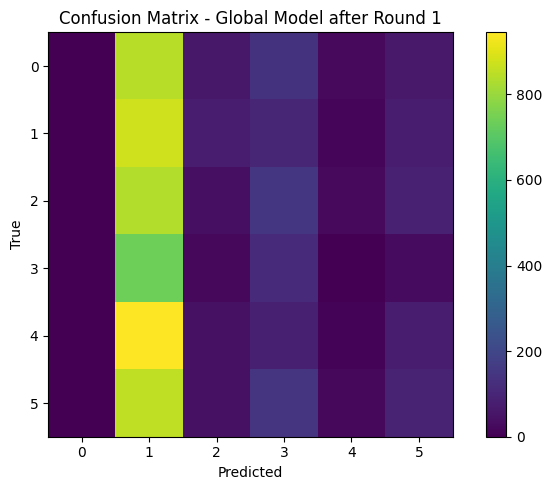


FEDERATED ROUND 2/5

Client 1 (Hospital-A) streaming samples: 204
Update norm=4.2259, clip_scale=0.2366, DQA=0.8909

Client 2 (Hospital-B) streaming samples: 204
Update norm=2.1867, clip_scale=0.4573, DQA=0.0000

Client 3 (Hospital-C) streaming samples: 204
Update norm=3.8979, clip_scale=0.2565, DQA=0.8970

Client 4 (Hospital-D) streaming samples: 204
Update norm=3.9765, clip_scale=0.2515, DQA=0.0000
\n======================================================================
Global Model after Round 2
accuracy            : 0.1439
balanced_accuracy   : 0.1525
precision_macro     : 0.1465
recall_macro        : 0.1525
f1_macro            : 0.0796
mcc                 : -0.0182
\nClassification report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      1133
           1       0.17      0.50      0.25      1140
           2       0.22      0.03      0.05      1135
           3       0.11      0.39      0.18       903
           4       0.00 

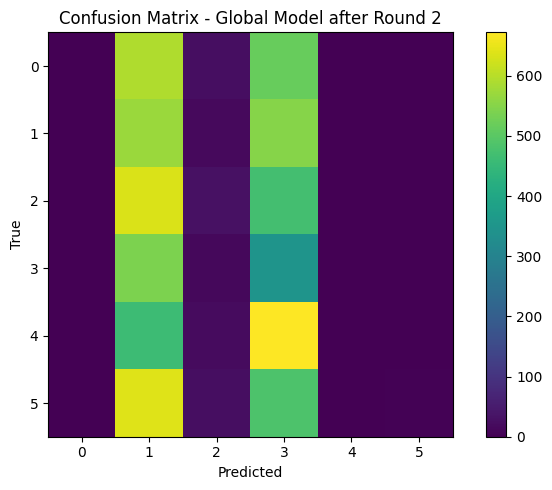


FEDERATED ROUND 3/5

Client 1 (Hospital-A) streaming samples: 204
Update norm=4.3207, clip_scale=0.2314, DQA=0.8199

Client 2 (Hospital-B) streaming samples: 204
Update norm=2.1454, clip_scale=0.4661, DQA=0.0000

Client 3 (Hospital-C) streaming samples: 204
Update norm=3.9274, clip_scale=0.2546, DQA=0.8888

Client 4 (Hospital-D) streaming samples: 204
Update norm=3.9563, clip_scale=0.2528, DQA=0.0000
\n======================================================================
Global Model after Round 3
accuracy            : 0.1670
balanced_accuracy   : 0.1618
precision_macro     : 0.0769
recall_macro        : 0.1618
f1_macro            : 0.0508
mcc                 : -0.0334
\nClassification report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      1133
           1       0.17      0.96      0.29      1140
           2       0.00      0.00      0.00      1135
           3       0.09      0.01      0.01       903
           4       0.00 

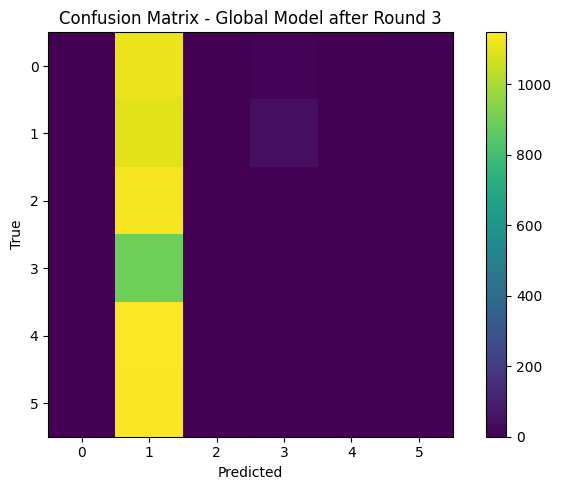


FEDERATED ROUND 4/5

Client 1 (Hospital-A) streaming samples: 204
Update norm=4.2857, clip_scale=0.2333, DQA=0.7955

Client 2 (Hospital-B) streaming samples: 204
Update norm=2.1351, clip_scale=0.4684, DQA=0.0000

Client 3 (Hospital-C) streaming samples: 204
Update norm=3.9285, clip_scale=0.2546, DQA=0.8449

Client 4 (Hospital-D) streaming samples: 204
Update norm=3.9964, clip_scale=0.2502, DQA=0.0000
\n======================================================================
Global Model after Round 4
accuracy            : 0.1646
balanced_accuracy   : 0.1592
precision_macro     : 0.0973
recall_macro        : 0.1592
f1_macro            : 0.0604
mcc                 : -0.0238
\nClassification report:
              precision    recall  f1-score   support

           0       0.22      0.01      0.02      1133
           1       0.17      0.91      0.28      1140
           2       0.12      0.03      0.05      1135
           3       0.00      0.00      0.00       903
           4       0.00 

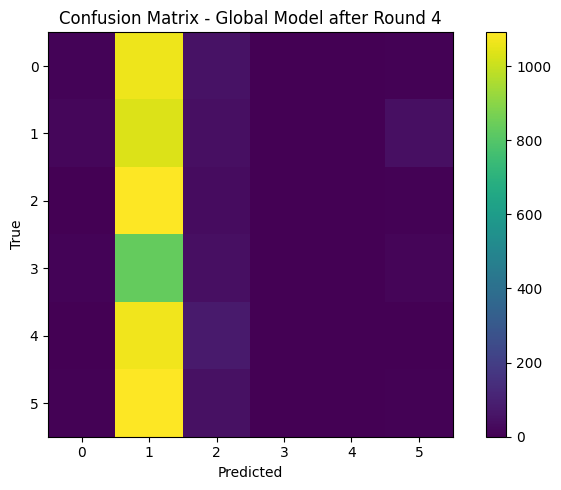


FEDERATED ROUND 5/5

Client 1 (Hospital-A) streaming samples: 204
Update norm=4.2945, clip_scale=0.2329, DQA=0.8230

Client 2 (Hospital-B) streaming samples: 204
Update norm=2.1116, clip_scale=0.4736, DQA=0.0000

Client 3 (Hospital-C) streaming samples: 204
Update norm=3.9972, clip_scale=0.2502, DQA=0.8920

Client 4 (Hospital-D) streaming samples: 204
Update norm=3.9336, clip_scale=0.2542, DQA=0.0000
\n======================================================================
Global Model after Round 5
accuracy            : 0.1660
balanced_accuracy   : 0.1607
precision_macro     : 0.0751
recall_macro        : 0.1607
f1_macro            : 0.0796
mcc                 : -0.0107
\nClassification report:
              precision    recall  f1-score   support

           0       0.12      0.01      0.01      1133
           1       0.17      0.72      0.27      1140
           2       0.16      0.23      0.19      1135
           3       0.00      0.00      0.00       903
           4       0.00 

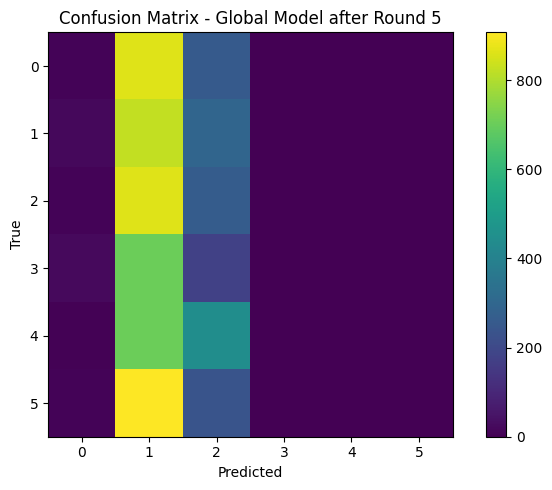

,round,client,samples,epochs,lr,raw_update_norm,clip_scale,dqa,final_loss,final_val_loss,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,mcc,epsilon_estimate,round_time_seconds
15,4,Hospital-D,204,1,0.0015,3.996442,0.250223,0.000000,1.773205,1.651362,0.164626,0.159236,0.097329,0.159236,0.060416,-0.02382,319.901727,33.912917
16,5,Hospital-A,204,2,0.0010,4.294531,0.232854,0.822989,1.544793,1.505348,0.165986,0.160704,0.075101,0.160704,0.079618,-0.01069,357.661004,34.061057
17,5,Hospital-B,204,1,0.0007,2.111608,0.473573,0.000000,1.749228,1.587105,0.165986,0.160704,0.075101,0.160704,0.079618,-0.01069,357.661004,34.061057
18,5,Hospital-C,204,3,0.0005,3.997175,0.250177,0.891983,1.570995,1.669004,0.165986,0.160704,0.075101,0.160704,0.079618,-0.01069,357.661004,34.061057
19,5,Hospital-D,204,1,0.0015,3.933617,0.254219,0.000000,1.724990,1.611198,0.165986,0.160704,0.075101,0.160704,0.079618,-0.01069,357.661004,34.061057


Saved logs and final global model to /kaggle/working


In [8]:
round_logs = []
global_weights = global_model.get_weights()

for rnd in range(1, FED_ROUNDS + 1):
    print("\n" + "="*80)
    print(f"FEDERATED ROUND {rnd}/{FED_ROUNDS}")
    print("="*80)

    participating_updates = []
    participating_counts = []
    client_logs = []

    round_start = time.time()

    for cid, (cx, cy) in enumerate(client_datasets):
        cfg = CLIENT_CONFIGS[cid]

        # Real-time component: each round only receives a new streaming chunk
        stream = make_realtime_stream(cx, cy, chunk_size=STREAM_CHUNK_SIZE)
        try:
            X_stream, y_stream = next(stream)
        except StopIteration:
            continue

        # Local train/validation split
        stratify_labels = np.argmax(y_stream, axis=1)
        unique_classes, class_counts = np.unique(stratify_labels, return_counts=True)

        can_stratify = (
            len(unique_classes) > 1
            and len(X_stream) >= 20
            and np.min(class_counts) >= 2
        )

        if can_stratify:
            X_local, X_val, y_local, y_val = train_test_split(
                X_stream,
                y_stream,
                test_size=0.20,
                random_state=SEED + rnd + cid,
                stratify=stratify_labels
            )
        else:
            X_local, X_val, y_local, y_val = train_test_split(
                X_stream,
                y_stream,
                test_size=0.20,
                random_state=SEED + rnd + cid,
                shuffle=True
            )

        print(f"\nClient {cid+1} ({cfg['name']}) streaming samples: {len(X_local)}")
        time.sleep(cfg["latency"])  # simulated real-time communication/computation delay

        local_model = clone_compiled_model(global_model, lr=cfg["lr"])
        old_weights = local_model.get_weights()

        callbacks = [
            tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True)
        ]

        history = local_model.fit(
            X_local, y_local,
            validation_data=(X_val, y_val),
            epochs=cfg["epochs"],
            batch_size=LOCAL_BATCH_SIZE,
            callbacks=callbacks,
            verbose=0
        )

        new_weights = local_model.get_weights()
        raw_update = get_update(new_weights, old_weights)

        clipped_update, raw_norm, clip_scale = clip_weights_update(raw_update, clip_norm=CLIP_NORM)
        private_update = add_gaussian_noise(clipped_update, noise_multiplier=NOISE_MULTIPLIER, clip_norm=CLIP_NORM)

        dqa = client_data_quality_score(history, y_local)

        participating_updates.append(private_update)
        participating_counts.append(len(X_local))

        client_logs.append({
            "round": rnd,
            "client": cfg["name"],
            "samples": len(X_local),
            "epochs": cfg["epochs"],
            "lr": cfg["lr"],
            "raw_update_norm": raw_norm,
            "clip_scale": clip_scale,
            "dqa": dqa,
            "final_loss": history.history["loss"][-1],
            "final_val_loss": history.history.get("val_loss", [np.nan])[-1],
        })

        print(f"Update norm={raw_norm:.4f}, clip_scale={clip_scale:.4f}, DQA={dqa:.4f}")

    # Secure aggregation simulation
    if participating_updates:
        agg_update = secure_aggregate_simulated(participating_updates, participating_counts)
        global_weights = apply_update(global_weights, agg_update)
        global_model.set_weights(global_weights)

    round_time = time.time() - round_start
    metrics = evaluate_model(global_model, X_global_test, y_global_test, title=f"Global Model after Round {rnd}", plot_roc=False)
    eps = estimate_epsilon(rnd, NOISE_MULTIPLIER, delta=DELTA)

    for log in client_logs:
        log.update(metrics)
        log["epsilon_estimate"] = eps
        log["round_time_seconds"] = round_time
        round_logs.append(log)

results_df = pd.DataFrame(round_logs)
display(results_df.tail())
results_df.to_csv("/kaggle/working/pp_hfl_realtime_round_logs.csv", index=False)
global_model.save("/kaggle/working/pp_hfl_realtime_global_model.keras")
print("Saved logs and final global model to /kaggle/working")

## Final Evaluation and Plots

\n======================================================================
Final PP-HFL Real-Time Global Model
accuracy            : 0.1660
balanced_accuracy   : 0.1607
precision_macro     : 0.0751
recall_macro        : 0.1607
f1_macro            : 0.0796
mcc                 : -0.0107
\nClassification report:
              precision    recall  f1-score   support

           0       0.12      0.01      0.01      1133
           1       0.17      0.72      0.27      1140
           2       0.16      0.23      0.19      1135
           3       0.00      0.00      0.00       903
           4       0.00      0.00      0.00      1153
           5       0.00      0.00      0.00      1151

    accuracy                           0.17      6615
   macro avg       0.08      0.16      0.08      6615
weighted avg       0.08      0.17      0.08      6615



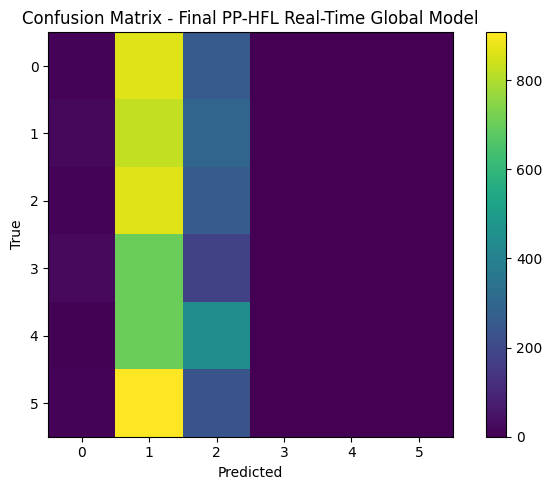

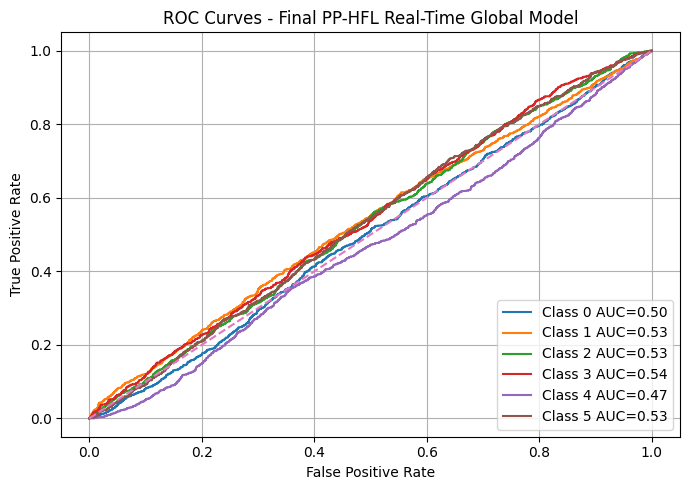

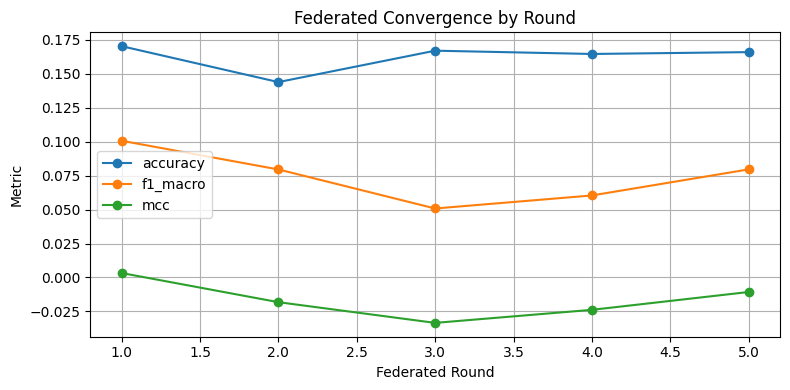

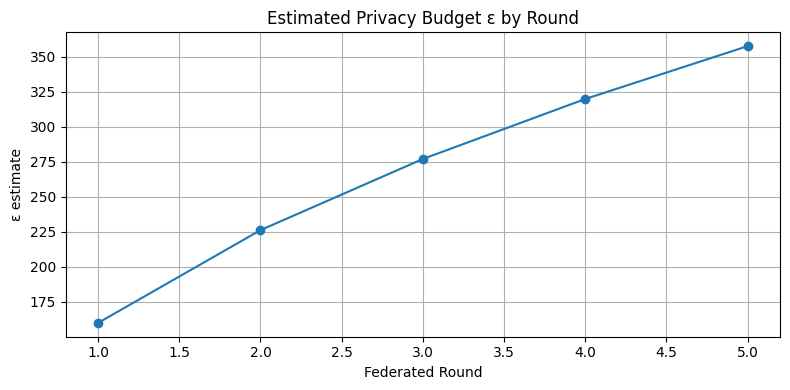

<Figure size 800x400 with 0 Axes>

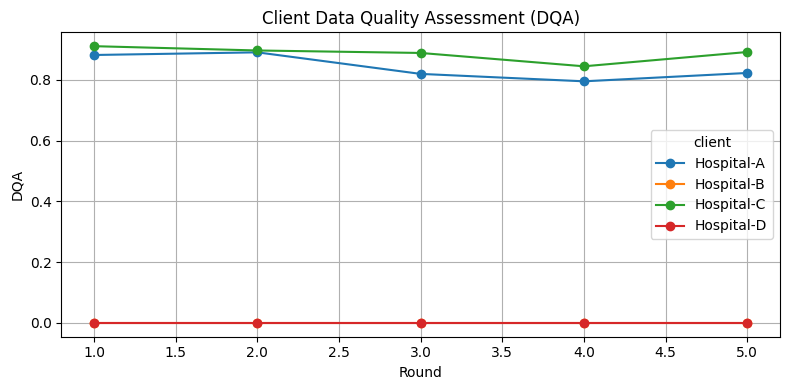

In [9]:
final_results = evaluate_model(global_model, X_global_test, y_global_test, title="Final PP-HFL Real-Time Global Model", plot_roc=True)
pd.DataFrame([final_results]).to_csv("/kaggle/working/pp_hfl_final_results.csv", index=False)

plt.figure(figsize=(8,4))
round_summary = results_df.groupby("round")[["accuracy", "f1_macro", "mcc"]].mean()
for col in round_summary.columns:
    plt.plot(round_summary.index, round_summary[col], marker="o", label=col)
plt.title("Federated Convergence by Round")
plt.xlabel("Federated Round")
plt.ylabel("Metric")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,4))
eps_by_round = results_df.groupby("round")["epsilon_estimate"].mean()
plt.plot(eps_by_round.index, eps_by_round.values, marker="o")
plt.title("Estimated Privacy Budget ε by Round")
plt.xlabel("Federated Round")
plt.ylabel("ε estimate")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,4))
dqa = results_df.groupby(["round", "client"])["dqa"].mean().unstack()
dqa.plot(marker="o", figsize=(8,4))
plt.title("Client Data Quality Assessment (DQA)")
plt.xlabel("Round")
plt.ylabel("DQA")
plt.grid(True)
plt.tight_layout()
plt.show()